In [ ]:
# ! pip install -U "jax[cuda12]"
# # ! pip install -U jax
# ! pip install -U  diffrax flax==0.10.2 distrax optax

In [ ]:
import distrax
import jax
import jax.numpy as jnp
import jax.random as jrnd
import optax
from flax import nnx

import diffrax
from diffrax import ODETerm, Euler, Dopri5, AbstractSolver, diffeqsolve
from tensorflow_probability.substrates import jax as tfp

import matplotlib
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

This tutorial aims to code Continuous Normalizing Flows (NFlows) in jax, using nnx and diffrax.

We recomend the reader the following papers.
* [Neural ODEs](https://arxiv.org/abs/1806.07366)
* [NFlows review](https://arxiv.org/abs/1912.02762)

We will focuse on the optimization of the forward and reverse KL divergence, as these are both, well use examples in ML.





The change of variable formula allows us to link two different probabilistic distributions,

$$
p_x(x) = p_z(z) |\text{det}\; J_{T}(z)|^{-1},
$$
where, $\text{det}\; J_{T}(z)$ is the determinant of Jacobian of the function $T(z) = x$ and $T^{-1}(x) = z$.
This volumen term can be computed through a set or joint ODEs,
$$
\partial_t \begin{bmatrix}
\mathbf{z}(t) \\
\log \rho_\phi(\mathbf{z}(t))
\end{bmatrix} =\begin{bmatrix}
g_\phi(\mathbf{z}(t),t) \\
-\nabla_{\mathbf{x}} \cdot g_\phi(\mathbf{z}(t),t)
\end{bmatrix},
$$
where the first term when integrated mimics the change from $x$ to $z$ or viserversa, and the second term indicates the change of the volumne part.
This set of ODEs are reversible, meaning the same of equations can be run in "reverse time".

In [ ]:
# NN to parameterize the set of ODE equations

# g_\phi(z(t),t)
class Flow(nnx.Module):
  def __init__(self, din: int, dim: int, rngs: nnx.Rngs):
    self.din, self.dim = din, dim
    self.linear_in = nnx.Linear(din + 1, dim, rngs=rngs)
    self.blocks = [
      nnx.Linear(dim, dim, rngs=rngs)
      for _ in range(3)
    ]
    self.linear_out = nnx.Linear(dim, din, rngs=rngs)

  def __call__(self, x, t):
    x = jnp.concatenate([x, t], axis=-1)
    x = self.linear_in(x)
    x = jnp.tanh(x)
    for block in self.blocks:
      x = block(x)
      x = jnp.tanh(x)
    x = self.linear_out(x)

    return x

# [g_\phi(\mathbf{z}(t),t) , -\nabla_{\mathbf{x}} \cdot g_\phi(\mathbf{z}(t),t)]
class CNF(nnx.Module):
  def __init__(self, din: int, dim: int, rngs: nnx.Rngs):
    self.din, self.dim = din, dim
    self.flow = Flow(din, dim, rngs)

  def __call__(self, states, t):

    x, log_px = states[:-1], states[-1:]
    dz, f_vjp = jax.vjp(self.flow, x,t)
    x_ones = jnp.ones((self.din))
    (dtrJ,_) = f_vjp(x_ones)
    dtrJ = jnp.sum(dtrJ)

    return jnp.concatenate([dz, -dtrJ[None]], axis=-1)


In [ ]:
data_dim: int = 1 # number of dimensions
model_dim: int = 264 # number of hidden neurons / layer
rngs = nnx.Rngs(0)

flow_model = CNF(data_dim, model_dim, rngs)
pred_flow = flow_model(jnp.ones((2)), jnp.array([0.]))
print(pred_flow)

# vmap to account for the batchsize dimension
@nnx.vmap(in_axes=(None, 0, 0), out_axes=0)
def forward(model, x, t):
  return model(x,t)

pred_flow_bs = forward(flow_model, jnp.ones((2,2)), jnp.array([[0.],[1.]]))
print(pred_flow_bs)


ERROR:2025-06-26 01:25:19,443:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.11/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/usr/local/lib/python3.11/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.
ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plu

[-0.1837502   0.07095978]
[[-0.1837502   0.07095978]
 [-0.34228671  0.08267832]]


# Forward KL divergence.
The forward KL divergence between the target distribution $p^∗_x(x)$ and the flow-based model
$p_x(x; \theta)$ can be written as follows,
$$
{\cal L}(\theta) = D_{KL}[p^∗_x(x) ||p_x(x; \theta) ] = - \mathbb{E}_{p^∗_x(x)}[\log p_x(x; \theta)] + const, \\
{\cal L}(\theta) = - \mathbb{E}_{p^∗_x(x)}[\log p_z(T^{-1}(x,\theta))+ \log |\text{det}\; J_{T^{-1}}(x, \theta)|] + const,
$$
the expecation value is constructed using only samples from the target distribution, $p^∗_x(x)$.
This allows us to compute the forward KL divergence using Monte Carlo,
$$
{\cal L}(\theta) \approx \frac{1}{N} \sum_i^N \log p_z(T^{-1}(x,\theta))+ \log |\text{det}\; J_{T^{-1}}(x, \theta)| + const
$$

Let's code this using the CNFlows.


In [ ]:
# define the base distribution p_z(z) using a single Gaussian distribution

base_dist = distrax.MultivariateNormalDiag(jnp.array([0.]), jnp.array([1.]))
def sample_pz(key, bs):
  z = base_dist.sample(seed=key, sample_shape=(bs,))
  log_pz = base_dist.log_prob(z)
  return jnp.concatenate([z,log_pz[:,None]], axis=-1)

key = jrnd.PRNGKey(0)
z_and_logpz = sample_pz(key, 100)

In [ ]:
# let's define the p^∗_x(x) (data distribution) using a mixture of gaussians.

base_dist0 = distrax.MultivariateNormalDiag(jnp.array([-2.]), jnp.array([0.5]))
base_dist1 = distrax.MultivariateNormalDiag(jnp.array([2.]), jnp.array([0.3]))
bimod_dist = distrax.MixtureOfTwo(0.5,base_dist0,base_dist1)

key = jrnd.PRNGKey(0)
_,key = jrnd.split(key)
x = bimod_dist.sample(seed=key, sample_shape=(100,1))
x = jnp.linspace(-10,10,100)
x = x[:,None]
p0 = bimod_dist.prob(x)

def sample_data_dist(key, bs): #bs is number of samples
  x = bimod_dist.sample(seed=key, sample_shape=(bs,))
  p0 = bimod_dist.prob(x)
  return jnp.concatenate([x,jnp.log(p0)[:,None]], axis=-1)

x_and_logpx = sample_data_dist(key, 2)

In [ ]:
# Forward KL divergence
def fwd_kl_div(flow_model, x_and_logpx):
  t0 = 0.
  t1 = 1.
  dt0 = t1 - t0
  flow_model.eval()
  # vector_field = lambda t, x, args: flow_model(x, jnp.full(x.shape[0], t))
  vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))
  term = ODETerm(vector_field)
  sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx,
                    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6),
                    saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
  z_and_logjac = sol.ys[-1,:,:]
  z = z_and_logjac[:,:-1]
  log_jac = z_and_logjac[:,-1]
  return -jnp.mean(base_dist.log_prob(z) - log_jac)

In [ ]:
@nnx.jit
def train_step(flow_model: Flow, optimizer: nnx.Optimizer, x_and_logpx):
  # print("compiling 'train_step' ...")
  loss, grads = nnx.value_and_grad(fwd_kl_div)(flow_model, x_and_logpx)
  optimizer.update(grads)
  return loss, optimizer

# tx = optax.adamw(2e-4,weight_decay=1E-5)
lr = optax.schedules.exponential_decay(2e-3, transition_steps = 1, decay_rate = 0.95)
tx = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(lr,weight_decay=1E-5)
        )
optimizer = nnx.Optimizer(flow_model, tx)

for itr in range(50):
    _,key = jrnd.split(key)
    x_and_logpx = sample_data_dist(key, 32) #sample 32 points form p^∗_x(x)
    x_and_logpx = x_and_logpx.at[:,-1].set(0.)
    loss, optimizer = train_step(flow_model, optimizer, x_and_logpx)
    # if itr % 10 == 0:
    print(itr, loss)

0 2.6433451024650263
1 5.92510275902429
2 3.406137370561851
3 1.836850249081392
4 2.372386722798997
5 1.8128574523072014
6 1.6922234897144963
7 1.4423988902479814
8 1.967362495239213
9 1.6836668126311718
10 1.4321081881064437
11 1.2766599745151292
12 1.836020958440355
13 1.3351368626808013
14 1.6311425114278995
15 1.743899962570553
16 1.889403911376664
17 1.9202383952551993
18 1.5706339298650343
19 1.261568903555767
20 1.234337871536845
21 1.2146333045266882
22 1.4187068186106369
23 1.3868321332340932
24 1.3910263537193228
25 1.2751652137120264
26 1.4708876134727926
27 1.2728626092760091
28 1.530887609294206
29 1.231867452197231
30 1.3809257799778383
31 1.3357671501300992
32 1.1386439043745353
33 1.150379395697639
34 1.427386394672517
35 1.2690485142565886
36 1.1413079034216336
37 1.2151080901483544
38 1.270498553567555
39 1.1010012736968593
40 1.1888201107446297
41 1.2167094532812228
42 1.6538208719105858
43 1.256890648563596
44 1.186325452398151
45 1.1714025247455013
46 1.28760524921

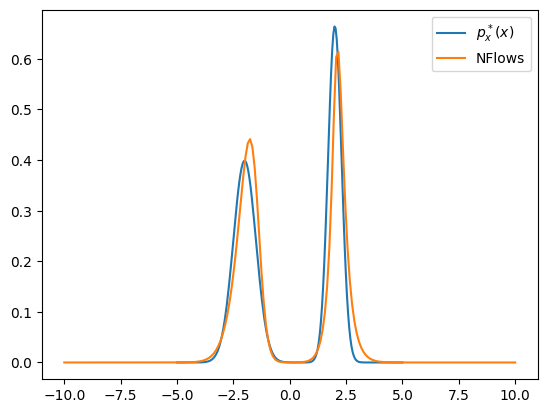

In [ ]:
# plot the distribution
x = jnp.linspace(-5,5,200)
x = x[:,None]
p0 = bimod_dist.prob(x)

plt.plot(x,p0,label=r'$p^*_x(x)$')

x = jnp.linspace(-10,10,200)
x = x[:,None]
x_and_logpx = jnp.concatenate([x,jnp.zeros((x.shape[0],1))], axis=-1)
t0 = 0.
t1 = 1.
dt0 = t1 - t0
flow_model.eval()
vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))

term = ODETerm(vector_field)
sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx, stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6), saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
z_and_logpz = sol.ys[-1,:,:]
z = z_and_logpz[:,:-1]
log_jac = z_and_logpz[:,-1:]
log_px_pred = base_dist.log_prob(z)[:,None] - log_jac

plt.plot(x,jnp.exp(log_px_pred).flatten(),label='NFlows')
plt.legend()

# Reverse KL Divergence.
Minimizing the reverse KL divergence,
$$
{\cal L}(\theta) = D_{KL}[p_x(x; \theta) || p^∗_x(x) ] = \mathbb{E}_{p_x(x,\theta)}[\log p_x(x; \theta)- \log p^∗_x(x)] , \\
{\cal L}(\theta) = \mathbb{E}_{p_z(z)}[\log p_z(z)- \log |\text{det}\; J_{T}(z, \theta)| - \log p^∗_x(x)]
$$
The last term in reverse KL is tricky as it means we should be able to compute the density of the data distribution.
Similarly to forward KL, we can compute it using MC,
$$
{\cal L}(\theta) \approx \frac{1}{N} \sum_i^N \log p_z(z_i)- \log |\text{det}\; J_{T}(z_i, \theta)| - \log p^∗_x(T(z_i))
$$

Let's code this using the CNFlows.

In [ ]:
def rev_kl_div(flow_model, z_and_logpz):
  t0 = 0.
  t1 = 1.
  dt0 = t1 - t0
  vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))
  term = ODETerm(vector_field)
  sol = diffeqsolve(term, diffrax.Tsit5(), t1, t0, -dt0, z_and_logpz, stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-4), saveat=diffrax.SaveAt(ts=jnp.array([1., 0.])))
  x_and_logpx = sol.ys[-1,:,:]
  x = x_and_logpx[:,:-1]
  log_px = x_and_logpx[:,-1:]
  log_px_true = jnp.log(bimod_dist.prob(x))[:,None]
  return jnp.mean(log_px - log_px_true)

In [ ]:
@nnx.jit
def train_step(flow_model: Flow, optimizer: nnx.Optimizer, x_and_logpx):
  loss, grads = nnx.value_and_grad(rev_kl_div)(flow_model, x_and_logpx)
  optimizer.update(grads)
  return loss, optimizer

lr = optax.schedules.exponential_decay(1e-5, transition_steps = 1, decay_rate = 0.95)
tx = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(lr,weight_decay=1E-5)
        )

optimizer = nnx.Optimizer(flow_model, tx)

for itr in range(20):
    _,key = jrnd.split(key)
    z_and_logpz = sample_pz(key, 64)
    loss, optimizer = train_step(flow_model, optimizer, z_and_logpz)
    if itr % 1 == 0:
      _,key = jrnd.split(key)
      z_and_logpz = sample_pz(key, 128)
      loss_val = rev_kl_div(flow_model, z_and_logpz)
      print(itr, loss, loss_val)

0 0.245471332587969 0.40031199708378773
1 0.007528892373457777 0.16709155792745212
2 0.31270793777697964 0.046975870955858194
3 0.16558725050837703 0.11543577427159266
4 0.022621120522092357 0.0794213244709076
5 0.05335227226125934 0.005029236813304259
6 0.16444081459912552 0.26471312694158133
7 0.26715306924055243 0.1269944457952454
8 0.09404903039597182 0.05852863600197415
9 0.2099316908599468 0.13320544947902085
10 -0.011261564064687531 0.11211140326029452
11 0.09127605357321272 0.07588307106270077
12 0.002223053949231844 0.0810939726672315
13 0.09165568774342447 0.13636616010560781
14 0.19768073331167718 0.14635923673406057
15 0.06700180398712399 0.1389661193657033
16 0.04444995836309495 0.10852026431247737
17 0.22692840871170955 0.09354760229329215
18 0.367551666488745 0.11248435983085271
19 0.15702616039575484 0.08360654468195948


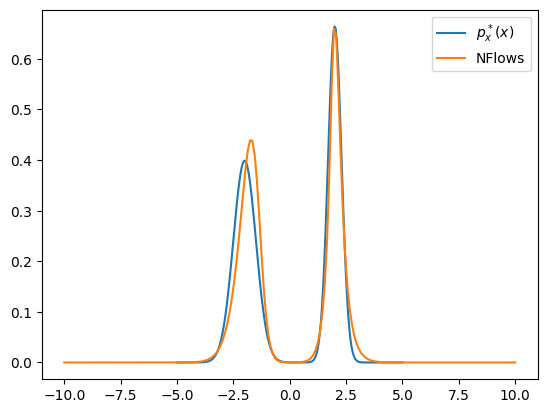

In [ ]:
# plot the distribution
x = jnp.linspace(-5,5,200)
x = x[:,None]
p0 = bimod_dist.prob(x)

plt.plot(x,p0,label=r'$p^*_x(x)$')

x = jnp.linspace(-10,10,200)
x = x[:,None]
x_and_logpx = jnp.concatenate([x,jnp.zeros((x.shape[0],1))], axis=-1)
t0 = 0.
t1 = 1.
dt0 = t1 - t0
flow_model.eval()
vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))

term = ODETerm(vector_field)
sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx, stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6), saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
z_and_logpz = sol.ys[-1,:,:]
z = z_and_logpz[:,:-1]
log_jac = z_and_logpz[:,-1:]
log_px_pred = base_dist.log_prob(z)[:,None] - log_jac

plt.plot(x,jnp.exp(log_px_pred).flatten(),label='NFlows')
plt.legend()

In [ ]:
# compute the density using numerical integration.
def rho_rev(model, x):
  x_and_logpx = jnp.concatenate([x,jnp.zeros((x.shape[0],1))], axis=-1)

  t0 = 0.
  t1 = 1.
  dt0 = t1 - t0
  flow_model.eval()
  vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))

  term = ODETerm(vector_field)
  sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx, stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6), saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
  z_and_logpz = sol.ys[-1,:,:]
  z = z_and_logpz[:,:-1]
  log_jac = z_and_logpz[:,-1:]
  log_px = base_dist.log_prob(z)[:,None] - log_jac
  return jnp.exp(log_px)

def integral(model, x_grid):
  p_x = rho_rev(model, x_grid)
  return jnp.trapezoid(p_x.flatten(),dx = x_grid[1]-x_grid[0]),p_x

In [ ]:
x_grid = jnp.linspace(-12,12,1000)[:,None]
norm_val, rho_pred = integral(flow_model,x_grid)
print('Integral value', norm_val)

Integral value 0.9999991012377577
